In [ ]:
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns

Create a good cluster_list

In [ ]:
df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_cluster_list_nanobody_mapping1.csv")
final_seqs = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\final_filtered_seqs_merged.csv")

cluster_df = (
    final_seqs
    .drop(columns=['Label'], errors='ignore')   
    .merge(df[['Nanobody_id', 'Label','Cluster_number', 'CDR_sequence']], on='Nanobody_id', how='inner')
)

print(cluster_df.head(1))
print(len(cluster_df))

       Nanobody_id                                           Sequence  \
0  Nb_e3fe0d0da712  QVQLQESGGGLVQAGGSLRLSCAASGNIFPADTMGWYRQAPGKERE...   

       CDR1     CDR2          CDR3   CDR1 with gaps CDR2 with gaps  \
0  GNIFPADT  IDDGTTT  AVNYRYDNYLYY  GNIF-------PADT     IDDG---TTT   

                  CDR3 with gaps  \
0  AVNYRY-----------------DNYLYY   

                                    Aligned Sequence  Label  Cluster_number  \
0  QVQLQESGG-GLVQAGGSL-RLSCAASGNIF-------PADTMGWY...      0           24294   

                  CDR_sequence  
0  GNIFPADTIDDGTTTAVNYRYDNYLYY  
182693


In [15]:
cluster_df.to_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_cluster_list_nanobody_mapping_new.csv", index=False)

Number of sequences in Round 1, Round 2 and Round 3

In [16]:
cluster_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_cluster_list_nanobody_mapping_new.csv")
round_1 = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\EG-1_nonredundant_unique.csv")
round_2 = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\EG-2_nonredundant_unique.csv")
round_3 = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\EG-3_nonredundant_unique.csv")


In [17]:
for i, df in enumerate([round_1, round_2, round_3], start=1):
    cluster_df.loc[
        cluster_df['Sequence'].isin(df['igghAaSequence']),
        'Round'
    ] = i

In [18]:
cluster_df['Round'] = cluster_df['Round'].values.astype('int')
print(cluster_df.head(1))
cluster_df.to_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_cluster_list_nanobody_mapping_new.csv", index=False)

       Nanobody_id                                           Sequence  \
0  Nb_e3fe0d0da712  QVQLQESGGGLVQAGGSLRLSCAASGNIFPADTMGWYRQAPGKERE...   

       CDR1     CDR2          CDR3   CDR1 with gaps CDR2 with gaps  \
0  GNIFPADT  IDDGTTT  AVNYRYDNYLYY  GNIF-------PADT     IDDG---TTT   

                  CDR3 with gaps  \
0  AVNYRY-----------------DNYLYY   

                                    Aligned Sequence  Label  Cluster_number  \
0  QVQLQESGG-GLVQAGGSL-RLSCAASGNIF-------PADTMGWY...      0           24294   

                  CDR_sequence  Round  
0  GNIFPADTIDDGTTTAVNYRYDNYLYY      1  


Dividing Rounds into train val test 

In [19]:
cluster_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_cluster_list_nanobody_mapping_new.csv")
print(cluster_df["Round"].value_counts())

Round
1    83564
2    59270
3    39859
Name: count, dtype: int64


Testing clusters

Round 1

In [ ]:
round1_df = cluster_df[cluster_df["Round"] == 1]
round2_df = cluster_df[cluster_df["Round"] == 2]
round3_df = cluster_df[cluster_df["Round"] == 3]

clusters_1 = round1_df["Cluster_number"].unique()
clusters_2 = round2_df["Cluster_number"].unique()
clusters_3 = round3_df["Cluster_number"].unique()
random.seed(42)
new_clusters1 = set(clusters_1) - set(clusters_2) - set(clusters_3)

round1_only_df = round1_df[round1_df["Cluster_number"].isin(new_clusters1)]

cluster_sizes = round1_only_df["Cluster_number"].value_counts()
total_seqs = cluster_sizes.sum()
target_seqs = int(total_seqs * 0.30)

print(f"Total seqs in Round1-only clusters: {total_seqs}")
print(f"Target 30% seqs: {target_seqs}")

cluster_list = list(cluster_sizes.index)
random.shuffle(cluster_list)

selected_clusters = []
selected_seq_count = 0

for cl in cluster_list:
    selected_clusters.append(cl)
    selected_seq_count += cluster_sizes[cl]
    if selected_seq_count >= target_seqs:
        break

print("Selected clusters:", selected_clusters)
print("Number of selected clusters:", len(selected_clusters))
print("Total sequences in selected clusters:", selected_seq_count)

seqs_0 = selected_seq_count
pd.DataFrame({"Cluster_number": selected_clusters}).to_csv(
    r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_test_clusters_round1_new.csv",
    index=False)

Total seqs in Round1-only clusters: 44518
Target 30% seqs: 13355
Selected clusters: [48043, 24593, 82682, 53942, 6367, 60640, 74674, 47280, 87812, 69377, 60612, 20006, 23160, 19082, 75549, 79607, 32904, 68019, 66356, 25452, 19597, 27564, 78945, 25967, 87901, 70081, 4122, 82900, 57575, 56333, 29486, 86904, 74069, 50011, 63441, 10313, 69558, 44986, 68129, 86343, 53614, 5192, 84475, 52462, 83876, 87505, 18771, 67778, 58281, 39510, 69573, 56420, 11618, 79707, 21394, 72419, 75197, 44049, 86065, 40971, 57376, 80235, 764, 15571, 50879, 2717, 61519, 79790, 62499, 42921, 29842, 67590, 45259, 48794, 34180, 78395, 80632, 81372, 74339, 17235, 42352, 63510, 91220, 4183, 77145, 10745, 72024, 13095, 78785, 63576, 55805, 26945, 34128, 41112, 8405, 76303, 77901, 77149, 9965, 64541, 469, 87054, 11841, 80417, 59329, 49166, 90324, 69275, 80355, 20390, 57811, 18967, 43544, 50184, 85447, 70645, 25491, 65365, 42200, 41101, 32032, 68130, 40355, 8859, 37536, 91643, 85524, 50329, 91144, 54581, 91747, 14830, 746

Round 3

In [ ]:
round3_df = cluster_df[cluster_df["Round"] == 3]
clusters_3 = round3_df["Cluster_number"].unique()
test_clusters = clusters_3
cluster_sizes3 = round3_df["Cluster_number"].value_counts()
cluster_list3 = list(cluster_sizes3.index)

total_seqs3 = cluster_sizes3.sum()
target_seqs3 = seqs_0

print(f"Total seqs in Round 3 clusters: {total_seqs3}")
print(f"Target number of seqs (Equal to Round 1): {target_seqs3}")

random.shuffle(cluster_list3)
seq_count3 = 0
selected_clusters3 = []

for cl in cluster_list3:
    selected_clusters3.append(cl)
    seq_count3 += cluster_sizes3[cl]
    if seq_count3 >= target_seqs3:
        break

print(f"Total clusters from Round 3: {len(test_clusters)}")

print("Selected clusters:", selected_clusters3)
print("Number of selected clusters:", len(selected_clusters3))
print("Total sequences in selected clusters containing Round 3 sequences:", seq_count3)

pd.DataFrame({"Cluster_number": selected_clusters3}).to_csv(
    r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_test_clusters_round3_new.csv",
    index=False
)

Total seqs in Round 3 clusters: 39859
Target number of seqs (Equal to Round 1): 13356
Total clusters from Round 3: 24826
Selected clusters: [5617, 13185, 18660, 84562, 41198, 22333, 40422, 73307, 21493, 54454, 47288, 85745, 82622, 41857, 21326, 26398, 37353, 44060, 63629, 88307, 4084, 6127, 26734, 18468, 82963, 898, 25792, 19880, 71277, 5980, 12382, 18646, 8371, 9791, 84887, 31735, 52112, 4675, 1782, 15661, 2895, 73627, 23613, 964, 9392, 32736, 54855, 5051, 6858, 66942, 44135, 21845, 12354, 20754, 4968, 40710, 74320, 20430, 24233, 22705, 23118, 7778, 3142, 47997, 7798, 14568, 65257, 4888, 32960, 666, 1191, 44815, 43671, 59695, 70227, 5286, 85836, 89277, 10470, 7671, 38318, 48325, 73411, 6197, 38532, 37228, 43753, 60914, 5353, 67416, 41776, 59388, 42611, 33584, 11658, 3780, 2943, 22409, 77569, 19962, 393, 1738, 5524, 18852, 10174, 29645, 3670, 18113, 68925, 37888, 4303, 76442, 11360, 23942, 18605, 4840, 10744, 85528, 13786, 8912, 77402, 36400, 102, 82727, 69293, 2821, 72364, 9681, 31991

Training and Validation clusters

Round 1

In [ ]:
test_clusters_round1 = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_test_clusters_round1_new.csv")
test_clusters_round3 = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_test_clusters_round3_new.csv")

round1_df = cluster_df[cluster_df["Round"] == 1]
round2_df = cluster_df[cluster_df["Round"] == 2]
round3_df = cluster_df[cluster_df["Round"] == 3]

clusters_1 = round1_df["Cluster_number"].unique()
clusters_2 = round2_df["Cluster_number"].unique()
clusters_3 = round3_df["Cluster_number"].unique()
random.seed(42)
new_clusters1 = set(clusters_1) - set(clusters_2) - set(clusters_3)
new_clusters2 = set(clusters_2) - set(clusters_3) -set(clusters_1)

round1_only_df = round1_df[round1_df["Cluster_number"].isin(new_clusters1)]
round2_only_df = round2_df[round2_df["Cluster_number"].isin(new_clusters2)]

round1_only_df_trainval = round1_only_df[~round1_only_df["Cluster_number"].isin(test_clusters_round1["Cluster_number"])]
round2_only_df_trainval = round2_only_df.copy()

round_trainval = pd.concat([round1_only_df_trainval, round2_only_df_trainval], ignore_index=True)
cluster_sizes = round_trainval["Cluster_number"].value_counts()

total_seqs = cluster_sizes.sum()
target_seqs = int(total_seqs * 0.10)

print(f"Total seqs in Round1-only clusters not in test clusters and Round 2 clusters: {total_seqs}")
print(f"Target 10% seqs for validation: {target_seqs}")

cluster_list = list(cluster_sizes.index)
random.shuffle(cluster_list)

selected_clusters = []
selected_seq_count = 0

for cl in cluster_list:
    selected_clusters.append(cl)
    selected_seq_count += cluster_sizes[cl]
    if selected_seq_count >= target_seqs:
        break

print("Selected clusters:", selected_clusters)
print("Number of selected clusters:", len(selected_clusters))
print("Total sequences in selected clusters:", selected_seq_count)

val_df = round_trainval[round_trainval["Cluster_number"].isin(selected_clusters)]
train_df = round_trainval[~round_trainval["Cluster_number"].isin(selected_clusters)]

train_cluster_set = set(train_df["Cluster_number"].unique())
val_cluster_set = set(val_df["Cluster_number"].unique())
test_cluster_set = set(test_clusters_round1["Cluster_number"]) | set(test_clusters_round3["Cluster_number"])

print("train ∩ val:", train_cluster_set & val_cluster_set)
print("train ∩ test:", train_cluster_set & test_cluster_set)
print("val ∩ test:", val_cluster_set & test_cluster_set)

pd.DataFrame({"Cluster_number": selected_clusters}).to_csv(
    r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_val_clusters_new.csv",
    index=False)
pd.DataFrame({"Cluster_number": train_df["Cluster_number"].unique()}).to_csv(
    r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_train_clusters_new.csv",
    index=False
)

Total seqs in Round1-only clusters not in test clusters and Round 2 clusters: 54411
Target 10% seqs for validation: 5441
Selected clusters: [70651, 89536, 70243, 25562, 39998, 29693, 72563, 50354, 67896, 66093, 79309, 44642, 72602, 59435, 76406, 82905, 68084, 63993, 15973, 86551, 80907, 31045, 77466, 4209, 80277, 67356, 57168, 26212, 68988, 5615, 12811, 44517, 41310, 69101, 89539, 63439, 61406, 77454, 89036, 27949, 14349, 62302, 84971, 86996, 40247, 12643, 88131, 59441, 56325, 48613, 71147, 51314, 66994, 15731, 58929, 83901, 84833, 85537, 70729, 53784, 47858, 77099, 79472, 11306, 54704, 21039, 21082, 87535, 57060, 60541, 17348, 41697, 16487, 87262, 57098, 6205, 55692, 83462, 54497, 55536, 73318, 40666, 75592, 23175, 21933, 43024, 68690, 60381, 66728, 50880, 55842, 74854, 32930, 68748, 44438, 87320, 88619, 60109, 80788, 90175, 34606, 69465, 53997, 41512, 19953, 26393, 38543, 22844, 89099, 42182, 78430, 76376, 89603, 69996, 84221, 49455, 21452, 87308, 35970, 37503, 48061, 62475, 45471, 6

Combine test clusters

In [ ]:
test_clusters1 = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_test_clusters_round1_new.csv")
test_clusters_round3 = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_test_clusters_round3_new.csv")

test_clusters = pd.concat([test_clusters1, test_clusters_round3], ignore_index=True)
test_clusters.to_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_test_clusters_concatenated_new.csv", index=False)


Get cluster stats

In [26]:
cluster_stats = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_cluster_stats70.csv")
train_clusters = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_train_clusters_new.csv")
val_clusters = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_val_clusters_new.csv")
test_clusters = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_test_clusters_concatenated_new.csv")

train_df = cluster_stats[cluster_stats["Cluster_number"].isin(train_clusters["Cluster_number"])]
val_df = cluster_stats[cluster_stats["Cluster_number"].isin(val_clusters["Cluster_number"])]
test_df = cluster_stats[cluster_stats["Cluster_number"].isin(test_clusters["Cluster_number"])]

train_df.to_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_train_clusters_new.csv", index=False)
val_df.to_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_val_clusters_new.csv", index=False)
test_df.to_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_test_clusters_concatenated_new.csv", index=False)

Get sequences for Train and Validation

In [ ]:
cluster_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_cluster_list_nanobody_mapping_new.csv")
train_seqs = cluster_df[cluster_df["Cluster_number"].isin(train_clusters["Cluster_number"])]
val_seqs = cluster_df[cluster_df["Cluster_number"].isin(val_clusters["Cluster_number"])]
train_seqs.to_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_train_seqs_new.csv", index=False)
val_seqs.to_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_val_seqs_new.csv", index=False)

Downsample test set

In [28]:
test_clusters = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\changed_test_clusters_concatenated_new.csv")
filtered_df = test_clusters[(test_clusters['label_0'] >= 5) | (test_clusters['label_1'] >= 5)]
print(filtered_df)
print(len(filtered_df))
normal_df = test_clusters[~test_clusters["Cluster_number"].isin(filtered_df["Cluster_number"])]

      Cluster_number  total_sequences  label_0  label_1
0                712              265        0      265
1                168              171        9      162
2                170              116        0      116
3              16232               66        0       66
4              20775               64        1       63
...              ...              ...      ...      ...
1671           20921                5        0        5
1673            2717                5        5        0
1676           38410                5        5        0
1677           19889                5        0        5
1680            5423                5        0        5

[923 rows x 4 columns]
923


In [29]:
test_normal_seqs = cluster_df[cluster_df["Cluster_number"].isin(normal_df["Cluster_number"])]
test_normal_seqs.to_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_test_normal_seqs_new.csv", index=False)

In [30]:
print(filtered_df.head(1))

   Cluster_number  total_sequences  label_0  label_1
0             712              265        0      265


In [ ]:
sampled_rows = []
test_clusters_filtered = cluster_df[cluster_df["Cluster_number"].isin(filtered_df["Cluster_number"])]
for cluster_id, group in test_clusters_filtered.groupby("Cluster_number"):
    summary_row = filtered_df[filtered_df["Cluster_number"] == cluster_id].iloc[0]
    if summary_row["label_0"] >= 5:
        label0_rows = group[group["Label"] == 0].sample(n=5, random_state=42)
        sampled_rows.append(label0_rows)
    if summary_row["label_1"] >= 5:
        label1_rows = group[group["Label"] == 1].sample(n=5, random_state=42)
        sampled_rows.append(label1_rows)

final_sampled_df = pd.concat(sampled_rows, ignore_index=True)
print(final_sampled_df)
final_sampled_df.to_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_test_filtered_seqs_new.csv", index=False)

          Nanobody_id                                           Sequence  \
0     Nb_7554852b2fa0  QVQLQESGGGLVQAGGSLRLSCAASGTISRNAWMGWYRQAPGKERE...   
1     Nb_5048ae83e9a0  QVQLQESGGGLVQAGGSLRLSCAASGTISRAWRMGWYRQAPGKERE...   
2     Nb_1cc97c3d90b1  QVQLQESGGGLVQAGGSLRLSCAASGTISRNAWMGWYRQAPGKERE...   
3     Nb_bff978b0361a  QVQLQESGGGLVQAGGSLRLSCAASGTISRNAWMGWYRQAPGKERE...   
4     Nb_076b8f1dc8f7  QVQLQESGGGLVQAGGSLRLSCAASGTISRNAWMGWYRQAPGKERE...   
...               ...                                                ...   
5100  Nb_33dc71ef06a2  QVQLQESGGGLVQAGGSLRLSCAASGSISQHRYMGWYRQAPGKERE...   
5101  Nb_ed4653a443af  QVQLQESGGGLVQAGGSLRLSCAASGSISDTRAMGWYRQAPGKERE...   
5102  Nb_12f78c477b78  QVQLQESGGGLVQAGGSLRLSCAASGSISTIVWMGWYRQAPGKERE...   
5103  Nb_4d85d2947df6  QVQLQESGGGLVQAGGSLRLSCAASGNISTTRYMGWYRQAPGKERE...   
5104  Nb_df701fd54966  QVQLQESGGGLVQAGGSLRLSCAASGTISSARYMGWYRQAPGKERE...   

          CDR1     CDR2              CDR3   CDR1 with gaps CDR2 with gaps  \
0     GTIS

Combine test seqs

In [32]:
test_normal_seqs = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_test_normal_seqs_new.csv")
test_filtered_seqs = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_test_filtered_seqs_new.csv")

test_seqs = pd.concat([test_normal_seqs, test_filtered_seqs], ignore_index=True)
test_seqs.to_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_test_seqs_new.csv", index=False)

Plots for data

C:\Users\ankit\AppData\Local\Temp\ipykernel_9928\3658574428.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=train_label_counts.index, y=train_label_counts.values, palette="Blues")


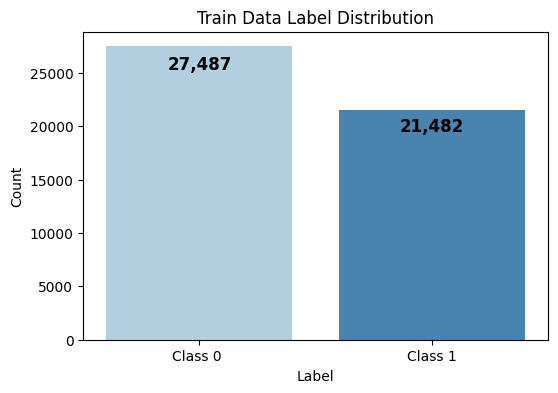

In [2]:
train_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_train_seqs_new.csv")
train_label_counts = train_df["Label"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=train_label_counts.index, y=train_label_counts.values, palette="Blues")
for i, v in enumerate(train_label_counts.values):
    ax.text(
        i, v - (0.03 * v), f"{v:,}", ha='center', va='top', color='black', fontsize=12, fontweight='bold'
    )
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Train Data Label Distribution')
plt.xticks([0, 1], labels=["Class 0 ", "Class 1"])
plt.savefig(r"D:\Thesis EGFR Round 3\Figures\train_data_label_distribution 70.png", dpi=300)
plt.show()

C:\Users\ankit\AppData\Local\Temp\ipykernel_9928\1032774359.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=val_label_counts.index, y=val_label_counts.values, palette="Reds")


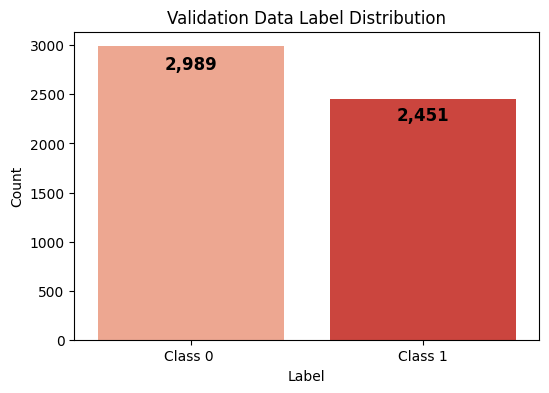

In [3]:
val_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_val_seqs_new.csv")
val_label_counts = val_df["Label"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=val_label_counts.index, y=val_label_counts.values, palette="Reds")
for i, v in enumerate(val_label_counts.values):
    ax.text(
        i, v - (0.03 * v), f"{v:,}", ha='center', va='top', color='black', fontsize=12, fontweight='bold'
    )
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Validation Data Label Distribution')
plt.xticks([0, 1], labels=["Class 0 ", "Class 1"])
plt.savefig(r"D:\Thesis EGFR Round 3\Figures\val_data_label_distribution 70.png", dpi=300)
plt.show()

36589


C:\Users\ankit\AppData\Local\Temp\ipykernel_9928\2305542161.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=test_label_counts.index, y=test_label_counts.values, palette="Greens")


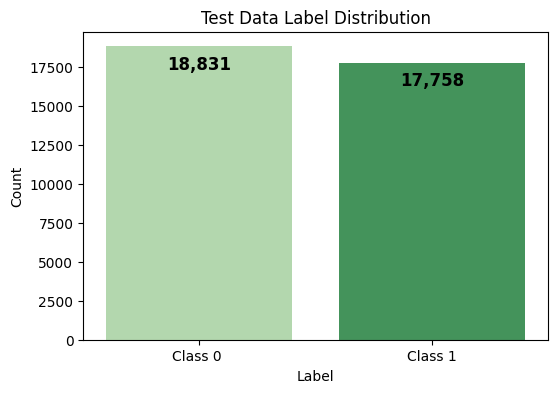

In [4]:
test_df = pd.read_csv(r"D:\Thesis EGFR Round 3\Dataset\Clustering\70\data\changed_test_seqs_new.csv")
print(len(test_df))
test_label_counts = test_df["Label"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=test_label_counts.index, y=test_label_counts.values, palette="Greens")
for i, v in enumerate(test_label_counts.values):
    ax.text(
        i, v - (0.03 * v), f"{v:,}", ha='center', va='top', color='black', fontsize=12, fontweight='bold'
    )
plt.xlabel('Label')
plt.ylabel('Count')
plt.title('Test Data Label Distribution')
plt.xticks([0, 1], labels=["Class 0 ", "Class 1"])
plt.savefig(r"D:\Thesis EGFR Round 3\Figures\test_data_label_distribution 70.png", dpi=300)
plt.show()

In [36]:
selected_clusters3_set = set(selected_clusters3)

print("Round 3 only:",
      len(cluster_df[
          (cluster_df["Cluster_number"].isin(selected_clusters3_set)) &
          (cluster_df["Round"] == 3)
      ]))

print("All rounds in selected clusters:",
      len(cluster_df[
          cluster_df["Cluster_number"].isin(selected_clusters3_set)
      ]))

print(cluster_df[
    cluster_df["Cluster_number"].isin(selected_clusters3_set)
]["Round"].value_counts())

Round 3 only: 13356
All rounds in selected clusters: 27259
Round
3    13356
1     7113
2     6790
Name: count, dtype: int64
